# 🏒 NHL Expected Goals (xG) Model
### Predicting the probability of a shot resulting in a goal using MoneyPuck shot data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Libraries loaded successfully!


In [2]:
df = pd.read_csv('shots_2024-2.csv')
print(df.shape)
df.head()

(119870, 137)


,shotID,arenaAdjustedShotDistance,arenaAdjustedXCord,arenaAdjustedXCordABS,arenaAdjustedYCord,arenaAdjustedYCordAbs,averageRestDifference,awayEmptyNet,awayPenalty1Length,awayPenalty1TimeLeft,...,xCordAdjusted,xFroze,xGoal,xPlayContinuedInZone,xPlayContinuedOutsideZone,xPlayStopped,xRebound,xShotWasOnGoal,yCord,yCordAdjusted
0,0,52.0,57.0,57.0,-41.0,41.0,0.0,0,0,0,...,57,0.238455,0.012537,0.394229,0.301072,0.022807,0.030900,0.710867,-40,-40
1,1,33.0,71.0,71.0,-28.0,28.0,-6.0,0,0,0,...,71,0.198306,0.021962,0.404919,0.313773,0.023774,0.037266,0.759039,-28,-28
2,2,48.0,48.0,48.0,-24.0,24.0,-12.6,0,0,0,...,48,0.213829,0.028057,0.405311,0.294682,0.025849,0.032272,0.696901,-24,-24
3,3,58.0,-40.0,40.0,-31.0,31.0,0.0,0,0,0,...,41,0.209478,0.009832,0.449775,0.277671,0.019667,0.033577,0.610530,-31,31
4,4,56.0,-35.0,35.0,15.0,15.0,0.0,0,0,0,...,36,0.376712,0.028884,0.307725,0.205568,0.022266,0.058845,0.799576,15,-15


In [3]:
df.columns.tolist()

['shotID',
 'arenaAdjustedShotDistance',
 'arenaAdjustedXCord',
 'arenaAdjustedXCordABS',
 'arenaAdjustedYCord',
 'arenaAdjustedYCordAbs',
 'averageRestDifference',
 'awayEmptyNet',
 'awayPenalty1Length',
 'awayPenalty1TimeLeft',
 'awaySkatersOnIce',
 'awayTeamCode',
 'awayTeamGoals',
 'defendingTeamAverageTimeOnIce',
 'defendingTeamAverageTimeOnIceOfDefencemen',
 'defendingTeamAverageTimeOnIceOfDefencemenSinceFaceoff',
 'defendingTeamAverageTimeOnIceOfForwards',
 'defendingTeamAverageTimeOnIceOfForwardsSinceFaceoff',
 'defendingTeamAverageTimeOnIceSinceFaceoff',
 'defendingTeamDefencemenOnIce',
 'defendingTeamForwardsOnIce',
 'defendingTeamMaxTimeOnIce',
 'defendingTeamMaxTimeOnIceOfDefencemen',
 'defendingTeamMaxTimeOnIceOfDefencemenSinceFaceoff',
 'defendingTeamMaxTimeOnIceOfForwards',
 'defendingTeamMaxTimeOnIceOfForwardsSinceFaceoff',
 'defendingTeamMaxTimeOnIceSinceFaceoff',
 'defendingTeamMinTimeOnIce',
 'defendingTeamMinTimeOnIceOfDefencemen',
 'defendingTeamMinTimeOnIceOfDefen

In [4]:
df[['event', 'goal']].head(10)

,event,goal
0,SHOT,0
1,MISS,0
2,SHOT,0
3,SHOT,0
4,MISS,0
5,MISS,0
6,SHOT,0
7,SHOT,0
8,SHOT,0
9,MISS,0


In [5]:
feature_cols = ['shotDistance', 'shotAngleAdjusted', 'shotAnglePlusReboundSpeed', 
                'speedFromLastEvent', 'shotType', 'isPlayoffGame']

df[feature_cols + ['goal']].head(10)

,shotDistance,shotAngleAdjusted,shotAnglePlusReboundSpeed,speedFromLastEvent,shotType,isPlayoffGame,goal
0,51.224994,51.340192,0.000000,4.000000,WRIST,0,0
1,33.286634,57.264774,0.000000,14.867750,WRIST,0,0
2,47.507894,30.343249,0.000000,17.077031,SLAP,0,0
3,57.140179,32.855722,0.000000,10.095544,WRIST,0,0
4,55.081757,15.802514,0.000000,24.789111,SLAP,0,0
5,10.198039,11.309932,0.000000,5.326697,WRIST,0,0
6,13.038405,57.528808,46.218875,19.235384,WRIST,0,0
7,18.248288,80.537678,0.000000,10.118587,WRIST,0,0
8,46.861498,39.805571,15.042906,7.281183,SLAP,0,0
9,33.421550,51.072456,0.000000,7.195678,WRIST,0,0


In [7]:
df['shotAnglePlusReboundSpeed'].value_counts().head(10)

shotAnglePlusReboundSpeed
0.000000     89327
18.434949       72
45.000000       44
8.130102        43
26.565051       40
7.125016        37
11.309932       35
33.690068       24
12.528808       23
14.036243       22
Name: count, dtype: int64

In [9]:
df['shotType'] = df['shotType'].fillna('UNKNOWN')

# Verify it worked
df['shotType'].isnull().sum()

0

In [10]:
feature_cols = ['shotDistance', 'arenaAdjustedShotDistance', 'shotAngleAdjusted',
                'speedFromLastEvent', 'shotType', 'isPlayoffGame']

df[feature_cols + ['goal']].isnull().sum()

shotDistance                 0
arenaAdjustedShotDistance    0
shotAngleAdjusted            0
speedFromLastEvent           0
shotType                     0
isPlayoffGame                0
goal                         0
dtype: int64

In [11]:
df['goal'].value_counts()

goal
0    111442
1      8428
Name: count, dtype: int64

In [12]:
# Select our features and target
feature_cols = ['shotDistance', 'arenaAdjustedShotDistance', 'shotAngleAdjusted',
                'speedFromLastEvent', 'shotType', 'isPlayoffGame']

# One-hot encode shotType
df_model = pd.get_dummies(df[feature_cols], columns=['shotType'])

# Define X (features) and y (target)
X = df_model
y = df['goal']

print(X.shape)
print(X.columns.tolist())

(119870, 13)
['shotDistance', 'arenaAdjustedShotDistance', 'shotAngleAdjusted', 'speedFromLastEvent', 'isPlayoffGame', 'shotType_BACK', 'shotType_DEFL', 'shotType_SLAP', 'shotType_SNAP', 'shotType_TIP', 'shotType_UNKNOWN', 'shotType_WRAP', 'shotType_WRIST']


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} shots")
print(f"Test set: {X_test.shape[0]} shots")

Training set: 95896 shots
Test set: 23974 shots


In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [15]:
from sklearn.metrics import roc_auc_score, log_loss

y_pred_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
logloss = log_loss(y_test, y_pred_proba)

print(f"AUC-ROC: {auc:.4f}")
print(f"Log Loss: {logloss:.4f}")

AUC-ROC: 0.7279
Log Loss: 0.6149


In [16]:
feature_names = X.columns.tolist()
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)

print(coef_df)

                      Feature  Coefficient
8               shotType_SNAP     0.718651
7               shotType_SLAP     0.679436
12             shotType_WRIST     0.490719
10           shotType_UNKNOWN     0.395611
5               shotType_BACK     0.137996
4               isPlayoffGame     0.025623
1   arenaAdjustedShotDistance    -0.006221
2           shotAngleAdjusted    -0.017901
3          speedFromLastEvent    -0.020940
6               shotType_DEFL    -0.030648
0                shotDistance    -0.041935
9                shotType_TIP    -0.351009
11              shotType_WRAP    -0.368034


# Observations
Snap, Slaps and Wrist shots are more likely to lead to a goal. Playoff games don't create a enviorment where goals are more likely. Lastly Deflections, Tips and Wraps are less likely to lead to a goal.

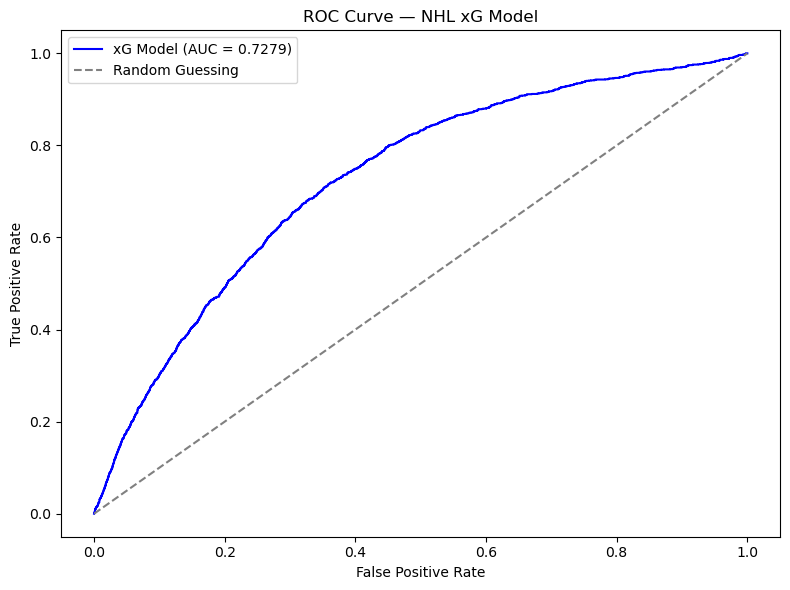

In [17]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'xG Model (AUC = {auc:.4f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — NHL xG Model')
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/_w/48_xr5cn7zs2dcc1972pmxlm0000gn/T/ipykernel_21397/221483757.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xg_by_type.index, y=xg_by_type.values, palette='Blues_r')


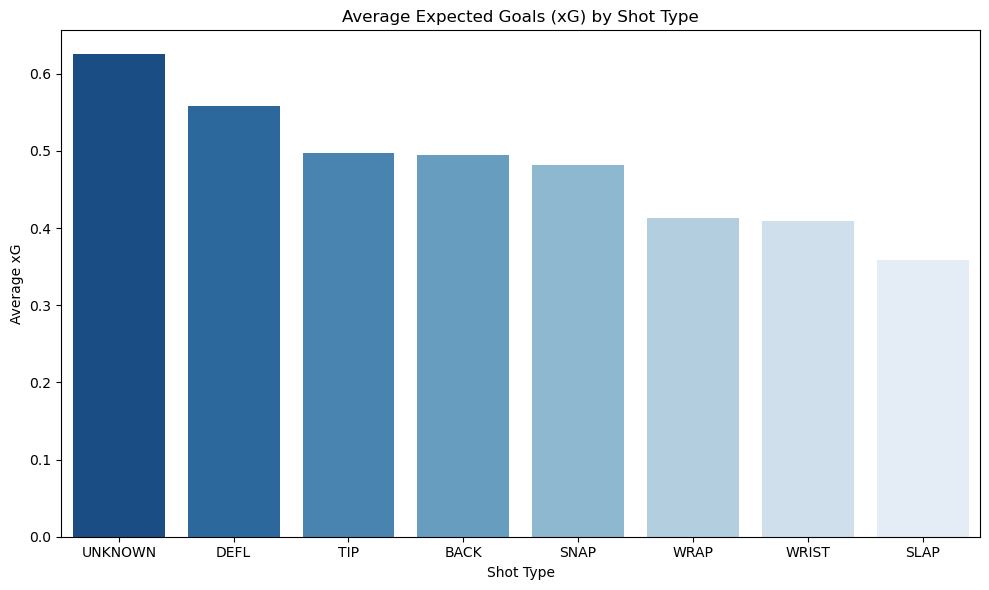

In [18]:
df['xG'] = model.predict_proba(df_model)[:, 1]

xg_by_type = df.groupby('shotType')['xG'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=xg_by_type.index, y=xg_by_type.values, palette='Blues_r')
plt.xlabel('Shot Type')
plt.ylabel('Average xG')
plt.title('Average Expected Goals (xG) by Shot Type')
plt.tight_layout()
plt.show()

## xG by Shot Type
Deflections produce the highest expected goal probability among known shot types, 
reflecting the difficulty goalies face tracking a redirected puck in tight spaces.
UNKNOWN shot types rank highest likely due to data quality issues rather than 
genuine hockey insight — a limitation worth noting.

In [20]:
from matplotlib.patches import Arc, Circle, Rectangle

def draw_rink(ax):
    # Rink outline
    ax.set_facecolor('#f0f0f0')
    rink = Rectangle((-42.5, 0), 85, 100, linewidth=2, edgecolor='black', facecolor='none')
    ax.add_patch(rink)
    
    # Goal crease
    crease = Arc((0, 89), width=12, height=7, angle=0, theta1=180, theta2=0, color='lightblue', linewidth=2)
    ax.add_patch(crease)
    
    # Goal line
    ax.axhline(y=89, xmin=0.15, xmax=0.85, color='red', linewidth=2)
    
    # Blue line
    ax.axhline(y=54, color='blue', linewidth=2)
    
    # Center line
    ax.axhline(y=0, color='red', linewidth=2)
    
    # Face-off circles
    circle1 = Circle((-20, 69), 15, linewidth=2, edgecolor='red', facecolor='none')
    circle2 = Circle((20, 69), 15, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(circle1)
    ax.add_patch(circle2)
    
    ax.set_xlim(-42.5, 42.5)
    ax.set_ylim(0, 100)
    ax.axis('off')

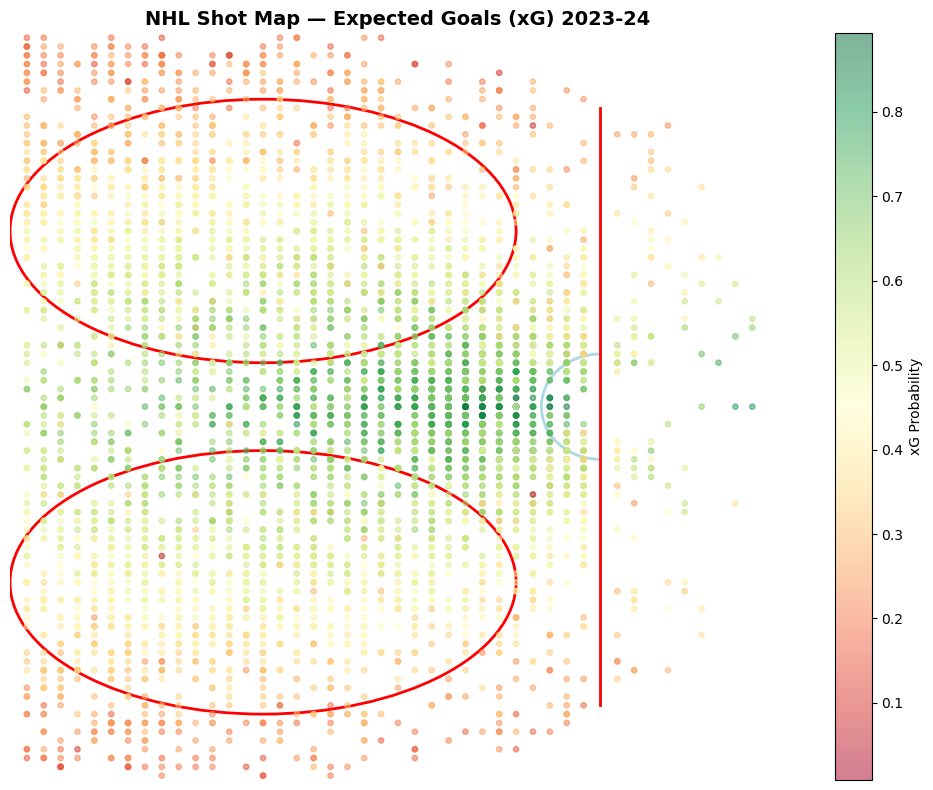

In [26]:
# Offensive zone only (x > 54 to end of rink)
shots_plot = df[df['xCordAdjusted'] > 54].sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor('#f0f0f0')

# Goal line
ax.axvline(x=89, ymin=0.1, ymax=0.9, color='red', linewidth=2)

# Face-off circles
circle1 = Circle((69, -20), 15, linewidth=2, edgecolor='red', facecolor='none')
circle2 = Circle((69, 20), 15, linewidth=2, edgecolor='red', facecolor='none')
ax.add_patch(circle1)
ax.add_patch(circle2)

# Crease
crease = Arc((89, 0), width=7, height=12, angle=0, theta1=90, theta2=270, color='lightblue', linewidth=2)
ax.add_patch(crease)

scatter = ax.scatter(
    shots_plot['xCordAdjusted'],
    shots_plot['yCordAdjusted'],
    c=shots_plot['xG'],
    cmap='RdYlGn',
    alpha=0.5,
    s=15
)

plt.colorbar(scatter, ax=ax, label='xG Probability')
ax.set_xlim(54, 100)
ax.set_ylim(-42.5, 42.5)
ax.axis('off')
plt.title('NHL Shot Map — Expected Goals (xG) 2023-24', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
xg_cols = [col for col in df.columns if 'xGoal' in col or 'xg' in col.lower()]
print(xg_cols)

['xGoal', 'xG']


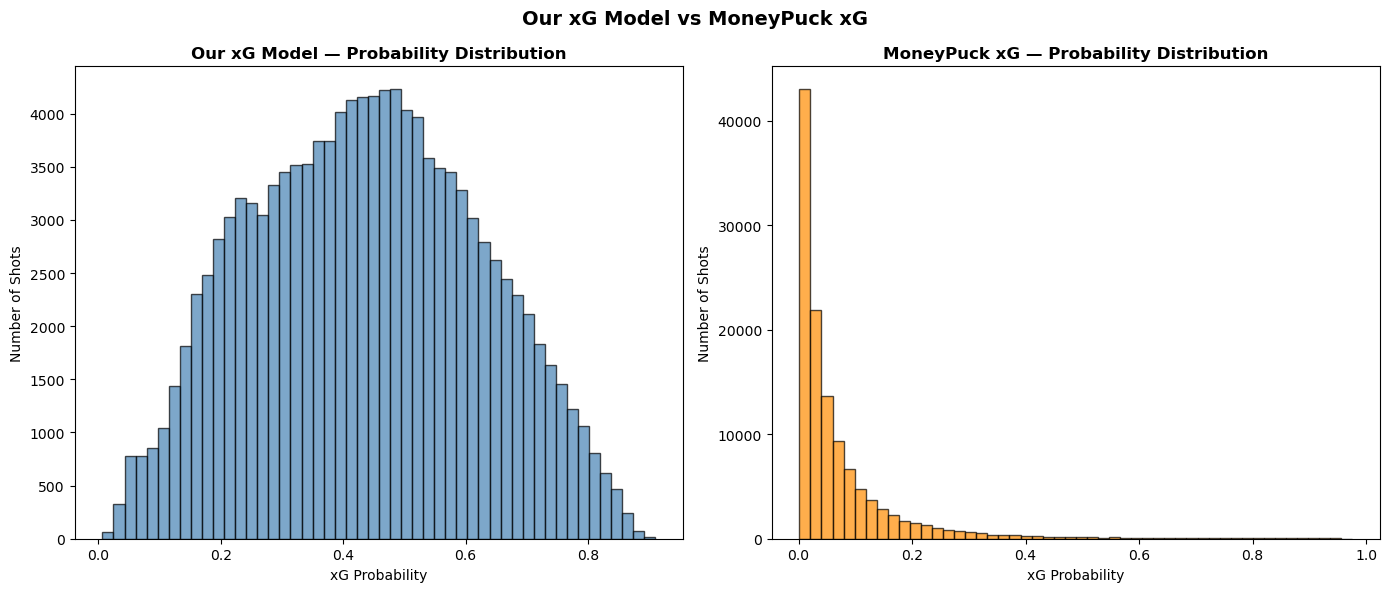

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Our model xG distribution
axes[0].hist(df['xG'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_title('Our xG Model — Probability Distribution', fontweight='bold')
axes[0].set_xlabel('xG Probability')
axes[0].set_ylabel('Number of Shots')

# MoneyPuck xG distribution
axes[1].hist(df['xGoal'], bins=50, color='darkorange', alpha=0.7, edgecolor='black')
axes[1].set_title('MoneyPuck xG — Probability Distribution', fontweight='bold')
axes[1].set_xlabel('xG Probability')
axes[1].set_ylabel('Number of Shots')

plt.suptitle('Our xG Model vs MoneyPuck xG', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Model Comparison: Our xG vs MoneyPuck
Our model overestimates shot probabilities compared to MoneyPuck's professional model. 
This is likely due to: (1) fewer features — we used 6 vs their dozens, (2) class_weight='balanced' 
pushing probabilities higher, and (3) Logistic Regression being less flexible than ensemble methods. 
A natural next step would be to implement XGBoost with additional features like traffic and game state.